# K-Nearest Neighbors (kNN) from Scratch

The aim of this notebook is to implement the **k-nearest neighbors** algorithm from scratch using only NumPy.

In [28]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [16]:
# Generate synthetic dataset
X, y = make_classification(n_samples=100, n_features=2, n_classes=2, n_informative=2, n_redundant=0, random_state=42)

In [17]:
X.shape, y.shape

((100, 2), (100,))

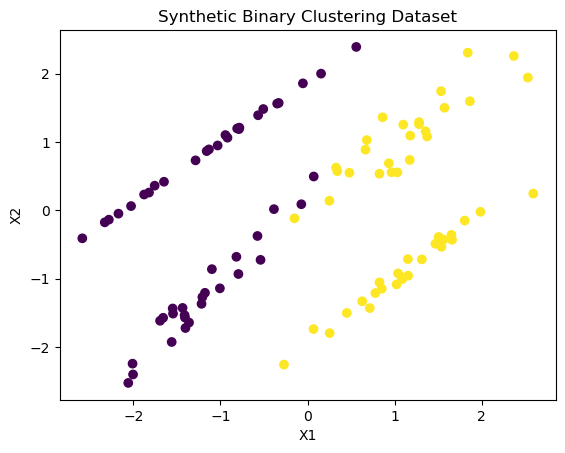

In [ ]:
# Visualize the dataset
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Synthetic Binary Classification Dataset")
plt.show()

In [19]:
# Euclidian distance 
def euclidian_distance(x1, x2):
    return np.linalg.norm(x1 - x2) # L2 norm, same as: np.sqrt(np.sum((p1 - p2)**2))

In [20]:
# Test with 2 simple vectors (ok)
euclidian_distance(x1=np.array([0, 0]), x2=np.array([3, 4]))

np.float64(5.0)

In [23]:
# Predict a single point, and return the class
def predict_one(x, X_train, y_train, k):
    # Compute the distance between x and each point of X_train
    distances = np.array([euclidian_distance(x, x_train) for x_train in X_train])
    # Order by increasing distance and store the indices
    ordered_indices = np.argsort(distances)
    # Keep first k-indices
    k_ordered_indices = ordered_indices[:k]
    # Get the corresponding labels
    labels = y_train[k_ordered_indices]
    # Return the majority class
    majority_class = np.bincount(labels).argmax()
    return majority_class

In [24]:
# Test the function with a single point and k=3
x_test = np.array([0.5, 0.5])
predict_one(x_test, X_train=X, y_train=y, k=3)

np.int64(1)

In [25]:
# Predict the class labels for all the points in X
def predict(X_test, X_train, y_train, k):
    y_pred = [predict_one(x, X_train, y_train, k) for x in X_test]
    return np.array(y_pred)

In [26]:
# Test the function with the training set (ok)
y_pred = predict(X_test=X, X_train=X, y_train=y, k=3)
accuracy_score(y, y_pred)

0.97

In [29]:
# Train and test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
# Predict the class labels for the test set
y_pred_test = predict(X_test=X_test, X_train=X_train, y_train=y_train, k=3)
accuracy_score(y_test, y_pred_test)

0.95

In [31]:
# Classification report
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       1.00      0.91      0.95        11
           1       0.90      1.00      0.95         9

    accuracy                           0.95        20
   macro avg       0.95      0.95      0.95        20
weighted avg       0.96      0.95      0.95        20



The results are very good (scores > 0.9), which is to be expected given the small and simple dataset we have.

In [32]:
# Decision boundary visualization
def plot_decision_boundary(X, y, model, k):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
    Z = model(np.c_[xx.ravel(), yy.ravel()], X_train=X_train, y_train=y_train, k=k)
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o')
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.title(f"KNN Decision Boundary (k={k})")
    plt.show()

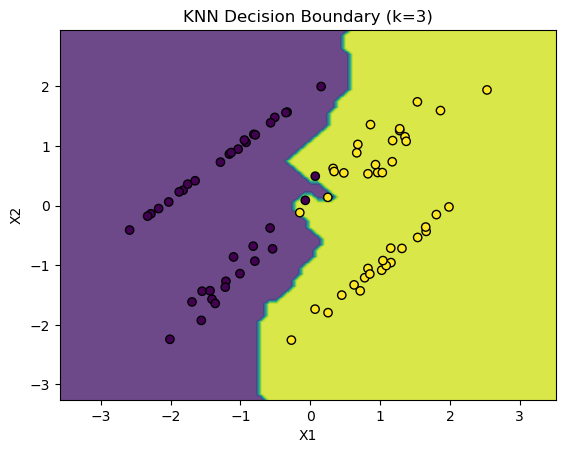

In [33]:
plot_decision_boundary(X=X_train, y=y_train, model=predict, k=3)

The **nonlinear boundary** is clearly visible, which is characteristic of KNN. Unlike logistic regression, which produced a straight line, here the boundary adapts locally to the data.